# Notizen: Kreuzungslogik & Duckiedetection

## Erkennen des Apriltags

**Problem:** Der Apriltag wird an der Kreuzung nicht erkannt, da der Bot zu nahe ist und der Apriltag nicht mehr im Sichtfeld ist.

**Idee:** Den oberen Bereich des Bildes analysieren (nicht nur den unteren), ob eine rote Linie darin ist – ähnlich wie beim "Kreuzung anhalten", jedoch nur um den zuletzt gesehenen Apriltag zu speichern. Dieser wird dann nach der Kreuzung zurückgesetzt.

## Befahren einer Kreuzung

**Idee:** Wenn Duckie an einer Kreuzung steht – Winkel und Entfernung zur Kreuzung berechnen.

**2 Möglichkeiten:**
1. An die Kreuzung fahren und anschließend `Kreuzung.py` ausführen
2. In `Kreuzung.py` diese Aktion mit aufnehmen, Fehler berechnen und darauf aufbauend die Kreuzung befahren

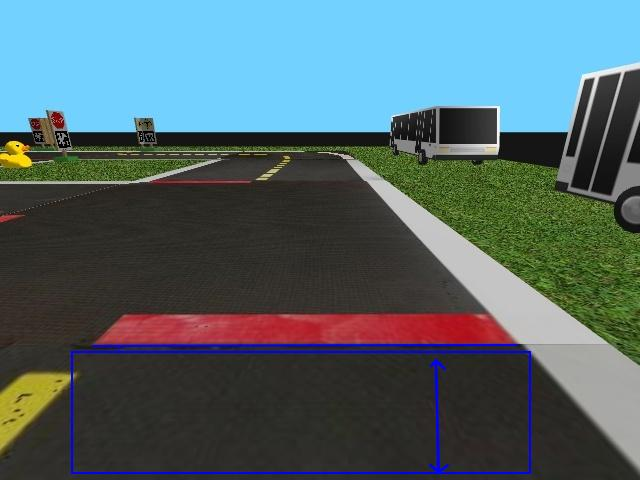

## Duckie Detection – Modell testen

In [4]:
import sys
!{sys.executable} -m pip install -q matplotlib onnxruntime

import onnxruntime as ort
import numpy as np
import cv2
from matplotlib import pyplot as plt

session = ort.InferenceSession("/tmp/duckie_v19.onnx")
input_name = session.get_inputs()[0].name
print("Modell geladen. Input:", session.get_inputs()[0].shape)

Modell geladen. Input: [1, 3, 480, 640]


In [5]:
IMAGE_PATH = "/root/DuckieRace/test0_jpg.rf.A8ZUDeF890gCpX98CNEJ.jpg"
CONF_THRESHOLD = 0.3

orig = cv2.imread(IMAGE_PATH)
img = cv2.resize(orig, (640, 480))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

inp = img_rgb.astype(np.float32) / 255.0
inp = np.transpose(inp, (2, 0, 1))
inp = np.expand_dims(inp, 0)

# Inferenz
raw_output = session.run(None, {input_name: inp})
detections = raw_output[0][0]  # shape: (300, 6) – alle erkannten Boxen

print(f"Output shape: {detections.shape}")

# Alle Boxen mit ausreichend hoher Confidence ausgeben
for i, box in enumerate(detections):
    x1, y1, x2, y2, conf, class_id = box
    if conf >= CONF_THRESHOLD:
        print(f"  Box {i}: x1={x1:.1f} y1={y1:.1f} x2={x2:.1f} y2={y2:.1f}  conf={conf:.3f}")

# Variable direkt anzeigen (erste 5 Boxen)
detections[:5]

Output shape: (300, 6)
  Box 0: x1=68.5 y1=257.0 x2=122.1 y2=314.5  conf=0.939
  Box 1: x1=348.6 y1=220.1 x2=400.6 y2=263.1  conf=0.915
  Box 2: x1=9.6 y1=328.4 x2=106.1 y2=439.2  conf=0.824
  Box 3: x1=293.2 y1=193.0 x2=321.6 y2=214.4  conf=0.455
  Box 4: x1=10.3 y1=328.2 x2=106.8 y2=439.5  conf=0.332


array([[6.85036011e+01, 2.56990784e+02, 1.22071037e+02, 3.14516327e+02,
        9.38836575e-01, 0.00000000e+00],
       [3.48647888e+02, 2.20105698e+02, 4.00562042e+02, 2.63146729e+02,
        9.14685249e-01, 0.00000000e+00],
       [9.55979919e+00, 3.28442749e+02, 1.06105415e+02, 4.39211914e+02,
        8.24029326e-01, 0.00000000e+00],
       [2.93225922e+02, 1.93001099e+02, 3.21581238e+02, 2.14366653e+02,
        4.55086261e-01, 0.00000000e+00],
       [1.02723312e+01, 3.28185455e+02, 1.06763962e+02, 4.39500305e+02,
        3.32148552e-01, 0.00000000e+00]], dtype=float32)

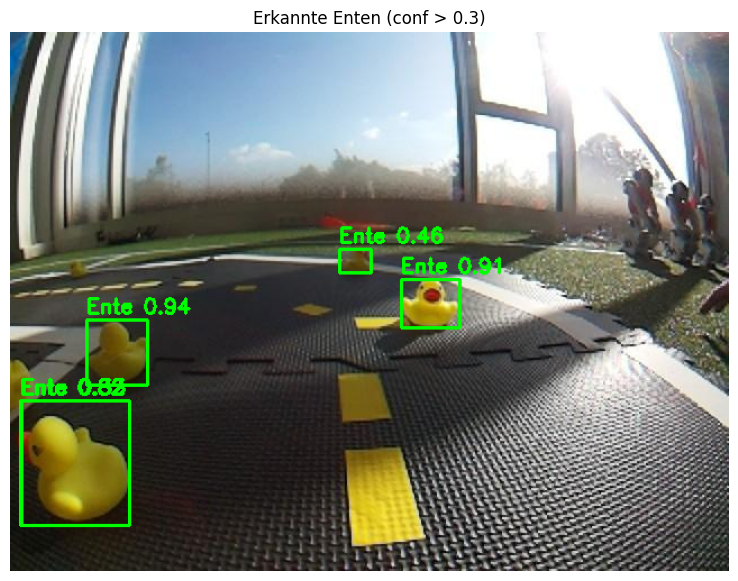

In [6]:
result_img = img_rgb.copy()

for box in detections:
    x1, y1, x2, y2, conf, class_id = box
    if conf < CONF_THRESHOLD:
        continue
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    cv2.rectangle(result_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(result_img, f"Ente {conf:.2f}", (x1, max(y1-6, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(12, 7))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Erkannte Enten (conf > {CONF_THRESHOLD})")
plt.show()